In [1]:
# Q6 (a)

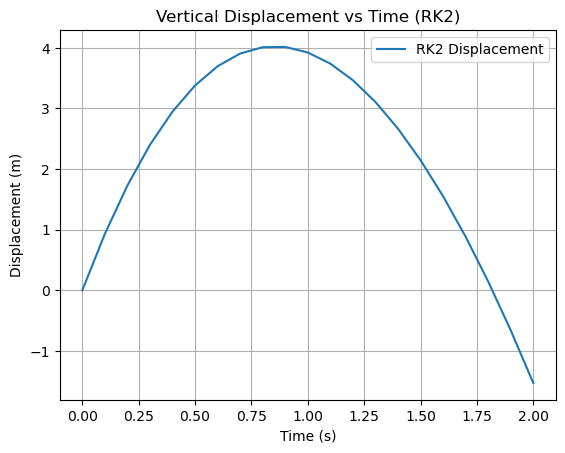

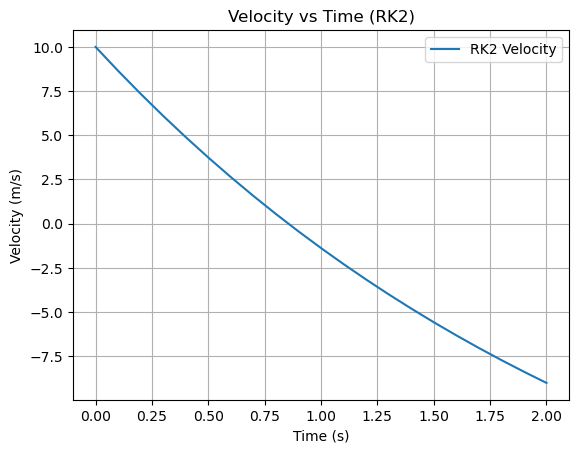

RK method second order result at t = 2.00 s: -9.0085 m/s


In [2]:
import numpy as np
import matplotlib.pyplot as plt


m = 0.5     
k = 0.2     
g = 9.81   

# Time settings
t0 = 0                 
total_time = 2           # total simulation time (s)
h = 0.1                  
t_values = np.arange(t0, total_time + h, h)  # array of time points

# Initial conditions
y0 = 0                  
v0 = 10                  

# Define the system of differential equations
def system_dynamics(t, y, v):
    """
    Compute derivatives:
    dy/dt = v (velocity)
    dv/dt = acceleration due to drag and gravity
    """
    dy_dt = v
    dv_dt = (-k * v - m * g) / m  # drag force + weight divided by mass
    return dy_dt, dv_dt

# Second order Runge-Kutta (RK2) numerical solver
def runge_kutta_second_order(f, y0, v0, t_values, h):
    # Initialize arrays to store displacement and velocity
    y_values = np.zeros_like(t_values)
    v_values = np.zeros_like(t_values)

    
    y_values[0] = y0
    v_values[0] = v0

    # Iterate through each time step to compute next values
    for i in range(len(t_values) - 1):
        t = t_values[i]
        y = y_values[i]
        v = v_values[i]

        # Calculate slopes at current time (k1)
        k1_y, k1_v = f(t, y, v)
        # Calculate slopes at next time using k1 values (k2)
        k2_y, k2_v = f(t + h, y + h * k1_y, v + h * k1_v)

        # Update displacement and velocity using average slope (RK2 formula)
        y_values[i + 1] = y + h / 2 * (k1_y + k2_y)
        v_values[i + 1] = v + h / 2 * (k1_v + k2_v)

    return y_values, v_values

# Run the RK2 solver
y_values, v_values = runge_kutta_second_order(system_dynamics, y0, v0, t_values, h)

# Plot displacement vs time
plt.plot(t_values, y_values, label="RK2 Displacement")
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Vertical Displacement vs Time (RK2)')
plt.grid(True)
plt.legend()
plt.show()

# Plot velocity vs time
plt.plot(t_values, v_values, label="RK2 Velocity")
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity vs Time (RK2)')
plt.grid(True)
plt.legend()
plt.show()


final_time_RK = t_values[-1]        # last time value
final_velocity_RK = v_values[-1]    # velocity at last time

print(f"RK method second order result at t = {final_time_RK:.2f} s: {final_velocity_RK:.4f} m/s")


In [4]:
# 06 (b)

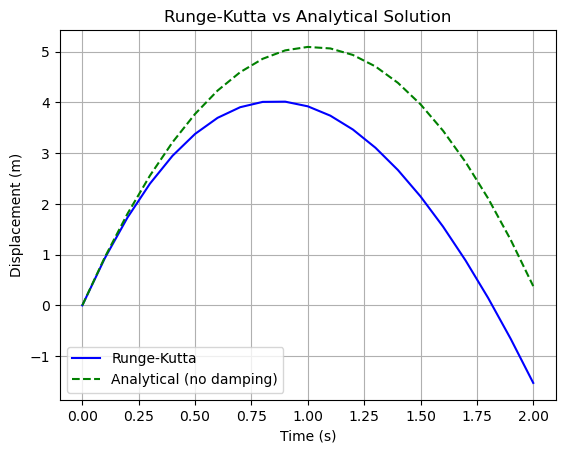

In [5]:
import numpy as np
import matplotlib.pyplot as plt

m = 0.5
k = 0.2
g = 9.81

t0 = 0
total_time = 2
h = 0.1
t_values = np.arange(t0, total_time + h, h)

y0 = 0
v0 = 10

def system_dynamics(t, y, v):
    # dy/dt = velocity, dv/dt = acceleration including drag and gravity
    dy_dt = v
    dv_dt = (-k * v - m * g) / m
    return dy_dt, dv_dt

def runge_kutta_second_order(f, y0, v0, t_values, h):
    y_values = np.zeros_like(t_values)
    v_values = np.zeros_like(t_values)

    # Initialize first values with initial conditions
    y_values[0] = y0
    v_values[0] = v0

    for i in range(len(t_values) - 1):
        t = t_values[i]
        y = y_values[i]
        v = v_values[i]

        # Calculate slopes (k1) at current time
        k1_y, k1_v = f(t, y, v)
        # Calculate slopes (k2) at next time using k1 estimates
        k2_y, k2_v = f(t + h, y + h * k1_y, v + h * k1_v)

        # Update y and v with average slopes (RK2 update formula)
        y_values[i + 1] = y + h / 2 * (k1_y + k2_y)
        v_values[i + 1] = v + h / 2 * (k1_v + k2_v)

    return y_values, v_values

y_values, v_values = runge_kutta_second_order(system_dynamics, y0, v0, t_values, h)

# Analytical solution without damping (for comparison)
y_analytical = -0.5 * g * t_values**2 + v0 * t_values

plt.plot(t_values, y_values, 'b-', label='Runge-Kutta')
plt.plot(t_values, y_analytical, 'g--', label='Analytical (no damping)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Runge-Kutta vs Analytical Solution')
plt.legend()
plt.grid(True)
plt.show()
